![Obesity-and-Eating-Habits-header](header.png)

# Term Project
## Names: Hannah Merrill (hem2479) and Kaylee Kim 

## 1. Project Overview

The goal of this project is to analyze and segment individuals based on their **lifestyle, dietary habits, and physical conditions** using the Obesity dataset. Rather than relying solely on traditional, predefined weight categories, this project leverages unsupervised machine learning techniques to uncover natural, hidden groupings within the population. 

By applying a **Gaussian Mixture Model (GMM)**, we will categorize individuals into distinct "health risk clusters" based on multidimensional data such as physical activity, daily caloric intake, transportation methods, and family history. Ultimately, this project aims to provide a deeper understanding of the behavioral and physiological profiles that contribute to obesity, which can inform more personalized health interventions and lifestyle recommendations.

## 2. Problem Statement
Obesity and related metabolic risks are driven by a complex interplay of genetic, dietary, and behavioral factors. Traditional diagnostic metrics often simplify this by looking primarily at **Body Mass Index (BMI) or broad weight classifications**, which fail to capture an individual's complete lifestyle profile (e.g., a person might be classified as overweight but maintain high physical activity and good hydration). 

The problem we seek to address is how to **accurately discover multidimensional behavioral patterns** without relying on predefined labels. By identifying distinct sub-populations based on comprehensive health and habit data, we can better understand the underlying risk profiles and tailor specific wellness strategies to each distinct cluster.

## 3. Data Overview


# Project Definition:

Model Used: Random Forest Classifier Multiclass Method

Dataset: "Obesity and Eating Habits" dataset from the UC Irvine Machine Learning Repository. The data comes from the paper 2019 "Dataset for estimation of obesity levels based on eating habits and physical condition in individuals from Colombia, Peru and Mexico," by Fabio Mendoza Palechor and Alexis De la Hoz Manotas. The dataset has estimations for the obesity levels of individuals, given eating habits and physical conditions, and contains 17 attributes and 2111 instances. The given features for each individual are Gender (m/f), Age (yrs), Height (m), Weight (kg), family history with overweight (y/n), eating vegetables with meals (never/sometimes/always), number of main meals daily (1-2, 3, >3), eating food between meals (no/sometimes/frequently/always), smoking (y/n), daily water intake (<1L, 1-2L, >2L), calorie monitoring (y/n), weekly physical activity (none/1-2 days/2-4 days/4-5 days), time on technological devices (0-2 hours/3-5 hours/>5 hours), alcohol consumption (never/sometimes/frequently/always), transportation (automobile, motorbike, bike, public transportatino, walking), and obesity level category based on BMI (Underweight, Normal, Overweight I, Overweight II, Overweight III, Obesity I, Obesity II, Obesity III). 

Research Question: Out of the features input features (excluding weight), which is the best predictor of obesity classification, and how accurately can the Random Forest Classifier classify a person given these inputs?

Current Expectation: 

Project Evaluation:

In [1]:
# Importing necessary libraries and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# Load the dataset
df = pd.read_csv('ObesityDataSet.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [3]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# Cleaning and Encoding Dataset

In [4]:
# Converting categorical variables to dummy variables
target_column = 'NObeyesdad'
X = df.drop(columns=[target_column, 'Weight'])
y = df[target_column]
X_encoded = pd.get_dummies(X)
print(X_encoded.head())
print(y.head())

# Encoding the obesity categories in 'NObeyesdad'
le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())

    Age  Height  FCVC  NCP  CH2O  FAF  TUE  Gender_Female  Gender_Male  \
0  21.0    1.62   2.0  3.0   2.0  0.0  1.0           True        False   
1  21.0    1.52   3.0  3.0   3.0  3.0  0.0           True        False   
2  23.0    1.80   2.0  3.0   2.0  2.0  1.0          False         True   
3  27.0    1.80   3.0  3.0   2.0  2.0  0.0          False         True   
4  22.0    1.78   2.0  1.0   2.0  0.0  0.0          False         True   

   family_history_with_overweight_no  ...  SCC_yes  CALC_Always  \
0                              False  ...    False        False   
1                              False  ...     True        False   
2                              False  ...    False        False   
3                               True  ...    False        False   
4                               True  ...    False        False   

   CALC_Frequently  CALC_Sometimes  CALC_no  MTRANS_Automobile  MTRANS_Bike  \
0            False           False     True              False        Fal

In [5]:
# 3. Splitting data into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)


# Using the Random Forest Multiclass Method

In [6]:
# 4. Initializing and Training the Random Forest Method
model = RandomForestClassifier(n_estimators=100, random_state=123)
model.fit(X_train, y_train)

# 5. Predicting obesity level based on input features
y_pred = model.predict(X_test)

# Calculating and printing the accuracy, precision, recall, and F1 of the model
score = model.score(X_test, y_test)
print(f"Accuracy of Classifier is: {score:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy of Classifier is: 0.86

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.93      0.93        56
      Normal_Weight       0.65      0.73      0.69        62
     Obesity_Type_I       0.92      0.85      0.88        78
    Obesity_Type_II       0.86      0.95      0.90        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.85      0.80      0.83        56
Overweight_Level_II       0.85      0.78      0.81        50

           accuracy                           0.86       423
          macro avg       0.86      0.86      0.86       423
       weighted avg       0.87      0.86      0.86       423



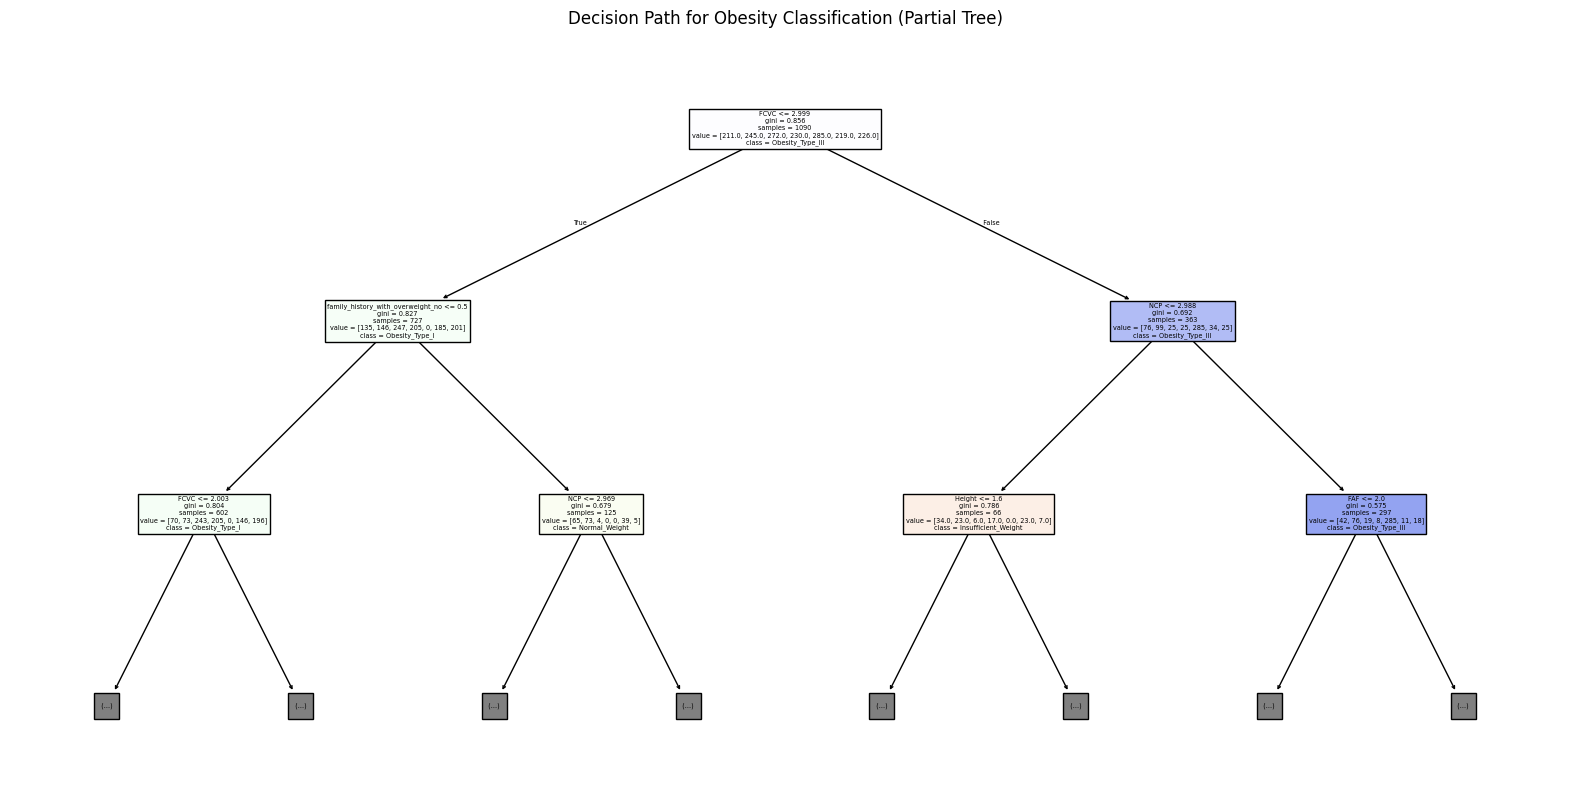

In [7]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

chosen_tree = model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(chosen_tree, feature_names=X_encoded.columns, class_names=le.classes_, filled=True, max_depth=2) 
plt.title("Decision Path for Obesity Classification (Partial Tree)")
plt.show()

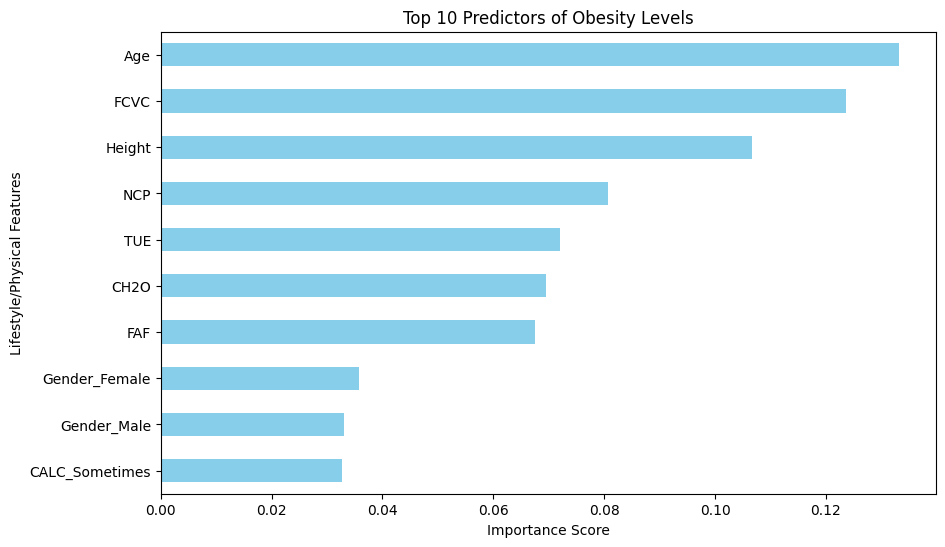

In [8]:
# Calculating feature importance
importances = pd.Series(model.feature_importances_, index=X_encoded.columns)
importances = importances.sort_values(ascending=False).head(10) # Top 10 features

# Plotting feature importance
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title("Top 10 Predictors of Obesity Levels")
plt.xlabel("Importance Score")
plt.ylabel("Lifestyle/Physical Features")
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

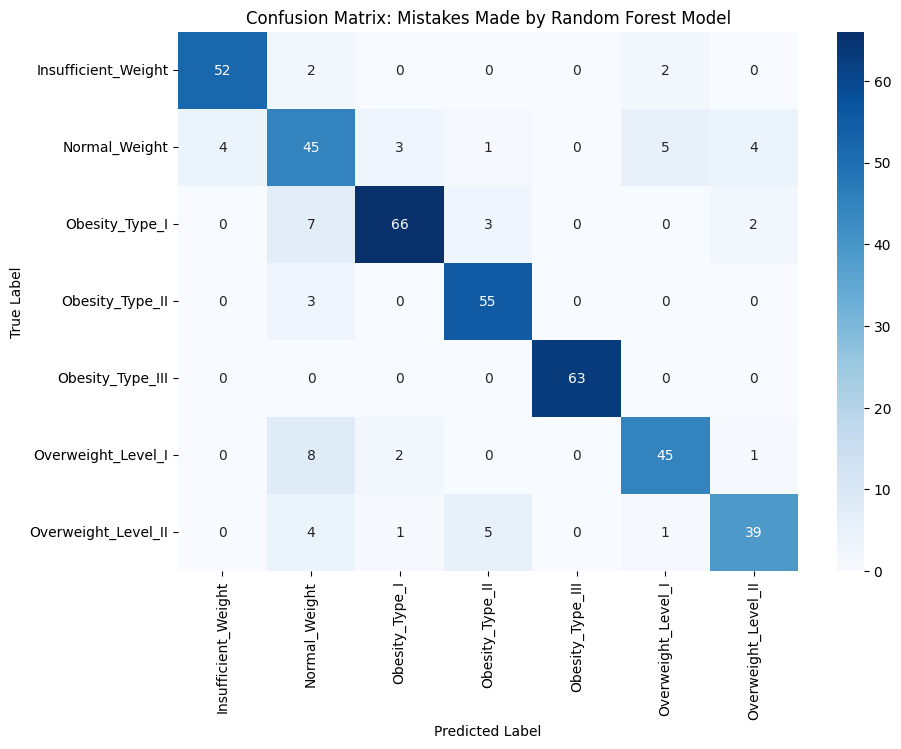

In [9]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Mistakes Made by Random Forest Model')
plt.show()